# Tag & Annotation Quality
In this notebook, we compute interrater agreement and analyse the quality per tag.

### Crawling from Google Drive

In [148]:
import gspread
import os
import pandas as pd

# init google sheets client
gc = gspread.service_account(filename="../service_account.json")

# load sheet URLs from file
sheets_file = "data/tags/curation/curated/sheets.txt"
with open(sheets_file, "r") as f:
    sheet_urls = [line.strip() for line in f.readlines() if line.strip()]

curated_dir = "data/tags/curation/curated"
sh_ids = []
for sheet_url in sheet_urls:
    sh = gc.open_by_url(sheet_url)

    # iterate through all worksheets and save as CSV
    for ws in sh.worksheets():
        # make output directory
        sh_id = sh.url.split("/")[-1]
        sh_ids.append(sh_id)
        output_dir = os.path.join(curated_dir, sh_id)
        os.makedirs(output_dir, exist_ok=True)
        output_file = os.path.join(output_dir, f"{ws.title}.csv")
        
        # save each worksheet as CSV
        df = pd.DataFrame(ws.get_all_records())
        df.to_csv(output_file, index=False)


### Reading the annotation files

In [149]:
dfs = []

for sh_id in set(sh_ids):
    dir_path = os.path.join(curated_dir, sh_id)
    if not os.path.isdir(dir_path):
        continue
    for fname in os.listdir(dir_path):
        if not fname.endswith(".csv"):
            continue
        if fname == "guidelines.csv":
            continue
        fpath = os.path.join(dir_path, fname)
        try:
            df_temp = pd.read_csv(fpath)
            df_temp["source_sheet"] = sh_id
            df_temp["tag"] = os.path.basename(fpath).split(".")[0].split("_")[1]
            dfs.append(df_temp)
        except Exception as e:
            print(f"Failed to read {fpath}: {e}")

if dfs:
    df = pd.concat(dfs, ignore_index=True)
else:
    df = pd.DataFrame()

df = df.dropna(subset=["tag_correct"])
print(f"Collected {len(dfs)} CSV files. Combined dataframe shape: {df.shape}")


Collected 36 CSV files. Combined dataframe shape: (1955, 18)


### Appending a column to document YouTube field where tag was found

In [150]:
import ast

def safe_to_list(val):
    """Convert val to a list safely."""
    if isinstance(val, (list, tuple, set)):
        return val
    elif isinstance(val, str):
        try:
            # convert string like '[tag1, tag2]' to list
            return list(ast.literal_eval(val))
        except:
            return []
    else:
        return []

def safe_to_dict(val):
    """Convert val to a dict safely."""
    if isinstance(val, dict):
        return val
    elif isinstance(val, str):
        try:
            return dict(ast.literal_eval(val))
        except:
            return {}
    else:
        return {}

def assign_tag_origin(df):
    """
    Assign the origin of each tag in 'tag' column.
    Hierarchical: yt_title > yt_description > yt_tags
    Handles NaN, None, and string representations.
    """
    origins = []

    for idx, row in df.iterrows():
        tag = row["tag"]

        tags_yt_title = safe_to_list(row.get("tags_yt_title"))
        tags_yt_description = safe_to_list(row.get("tags_yt_description"))
        tags_yt_tags = safe_to_list(row.get("tags_yt_tags"))
        m_tags = safe_to_dict(row.get("matched_tags_multilingual"))

        if tag in tags_yt_title or tag in m_tags.get("yt_title", []):
            origins.append("yt_title")
        elif tag in tags_yt_description or tag in m_tags.get("yt_description", []):
            origins.append("yt_description")
        elif tag in tags_yt_tags or tag in m_tags.get("yt_tags", []):
            origins.append("yt_tags")
        else:
            origins.append(None)

    return pd.Series(origins, index=df.index)

df["tag_in_field"] = assign_tag_origin(df)


### Inter-Annotator Agreement
First: transform to wide format.

In [151]:

# assume df contains: tag, clique, version, youtube_id, sh_id, tag_correct
id_cols = ["tag", "clique", "version", "youtube_id", "tag_in_field"]

# pivot: rows = items, columns = annotators
df_wide = df.pivot_table(
    index=id_cols,
    columns="source_sheet",
    values="tag_correct",
    aggfunc="first"
)

df_wide = df_wide.replace({"yes": 1, "no": 0})
df_wide2annots = df_wide.dropna(subset=sh_ids)


/tmp/ipykernel_463254/1920778568.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_wide = df_wide.replace({"yes": 1, "no": 0})


Now compute metrics:

In [152]:
import numpy as np
from sklearn.metrics import cohen_kappa_score

# extract ratings per annotator
annotators = df_wide2annots.columns.tolist()
r1 = df_wide2annots[annotators[0]].astype(int)
r2 = df_wide2annots[annotators[1]].astype(int)

# total pairs
n = len(r1)

# matches (same label)
matches = (r1 == r2)
n_matches = matches.sum()
rel_matches = n_matches / n

# mismatches (different labels)
n_mismatches = n - n_matches
rel_mismatches = n_mismatches / n

# general stats
print(f"Total pairs: {n}")
print(f"Matches: {n_matches} ({rel_matches:.2%})")
print(f"Mismatches: {n_mismatches} ({rel_mismatches:.2%})")

# cohen's kappa
kappa = cohen_kappa_score(r1, r2)
print("Cohen's kappa:", round(kappa, 4))


Total pairs: 451
Matches: 406 (90.02%)
Mismatches: 45 (9.98%)
Cohen's kappa: 0.7081


### Get long df

In [153]:
# Assume df_wide has MultiIndex and two annotator columns
colA, colB = df_wide2annots.columns[:2]  # first two columns are the annotators
id_cols = df_wide2annots.index.names       # your ID columns in the MultiIndex

# Reset index to get ID columns as regular columns
df_long2annots = df_wide2annots.reset_index().copy()

# Create a single vote column based on the two annotators
def summarize_vote(a, b):
    if a == b:
        if a == 1:
            return "correct"
        else:
            return "false"
    else:
        return "tie"

df_long2annots["vote_summary"] = df_long2annots.apply(lambda row: summarize_vote(row[colA], row[colB]), axis=1)
df_long2annots = df_long2annots[id_cols + ["vote_summary"]]


### Quality per Tag
We start with the agreement rows:

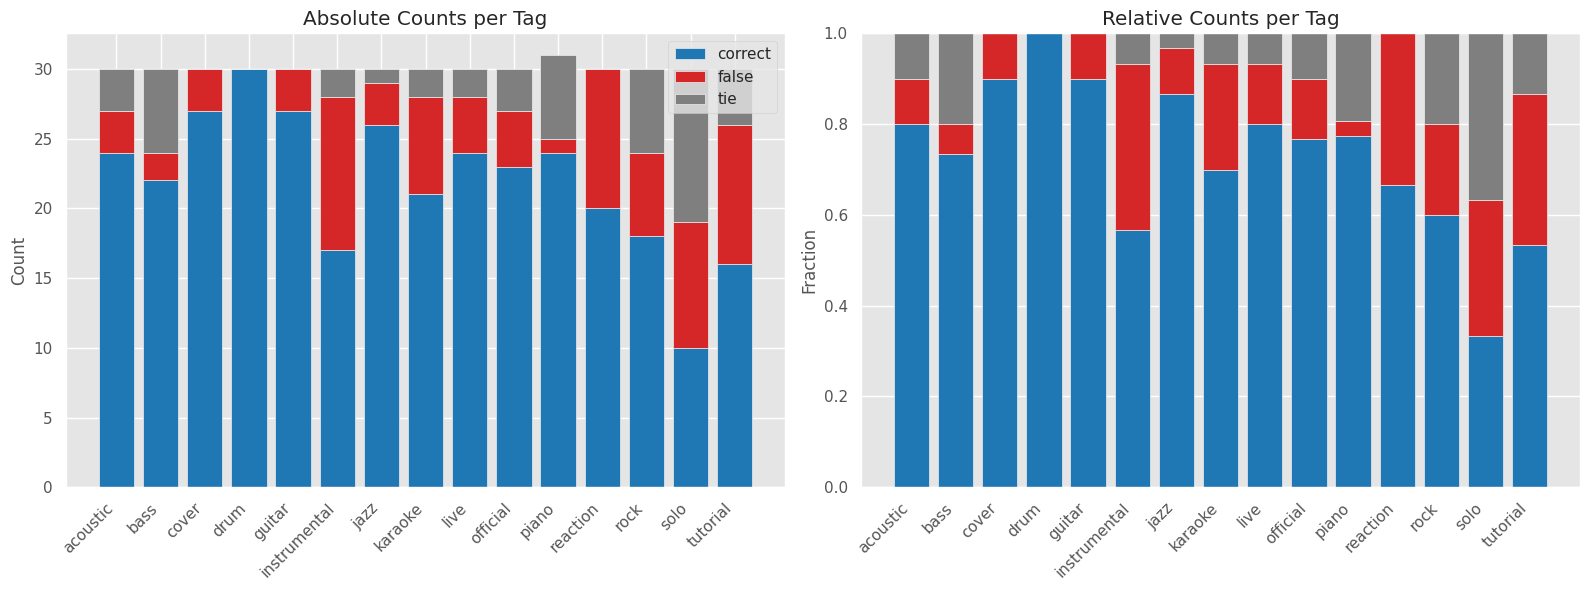

In [154]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plot_vote_summary(df_long, id_col="tag", vote_col="vote_summary"):
    """
    Create two stacked bar charts per tag/field:
    1. Absolute counts of 'correct', 'false', 'tie'
    2. Relative counts (percentages) of 'correct', 'false', 'tie'

    Args:
        df_long (pd.DataFrame): long-format dataframe with ID columns and vote_summary column
        id_col (str): column name to group by (e.g., 'tag')
        vote_col (str): column name with 'correct', 'false', 'tie'
    """
    
    # Aggregate counts per vote
    counts = df_long.groupby([id_col, vote_col]).size().unstack(fill_value=0)
    
    # Sort columns for consistent color mapping
    counts = counts.reindex(columns=["false", "tie", "correct"], fill_value=0)
    
    tags = counts.index
    x = np.arange(len(tags))
    
    colors = {
        "correct": "#1f77b4",  # blue
        "false":   "#d62728",  # red
        "tie":     "#7f7f7f"   # gray
    }  
    
    # --- Absolute counts ---
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    bottom = np.zeros(len(tags))
    for vote in ["correct", "false", "tie"]:
        axes[0].bar(x, counts[vote], bottom=bottom, color=colors[vote], label=vote)
        bottom += counts[vote].values
    
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(tags, rotation=45, ha='right')
    axes[0].set_ylabel("Count")
    axes[0].set_title("Absolute Counts per Tag")
    axes[0].legend()
    
    # --- Relative counts ---
    counts_rel = counts.div(counts.sum(axis=1), axis=0)
    
    bottom = np.zeros(len(tags))
    for vote in ["correct", "false", "tie"]:
        axes[1].bar(x, counts_rel[vote], bottom=bottom, color=colors[vote], label=vote)
        bottom += counts_rel[vote].values
    
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(tags, rotation=45, ha='right')
    axes[1].set_ylabel("Fraction")
    axes[1].set_title("Relative Counts per Tag")
    
    plt.tight_layout()
    plt.show()


plot_vote_summary(df_long2annots, id_col="tag", vote_col="vote_summary")

Only in YouTube Title

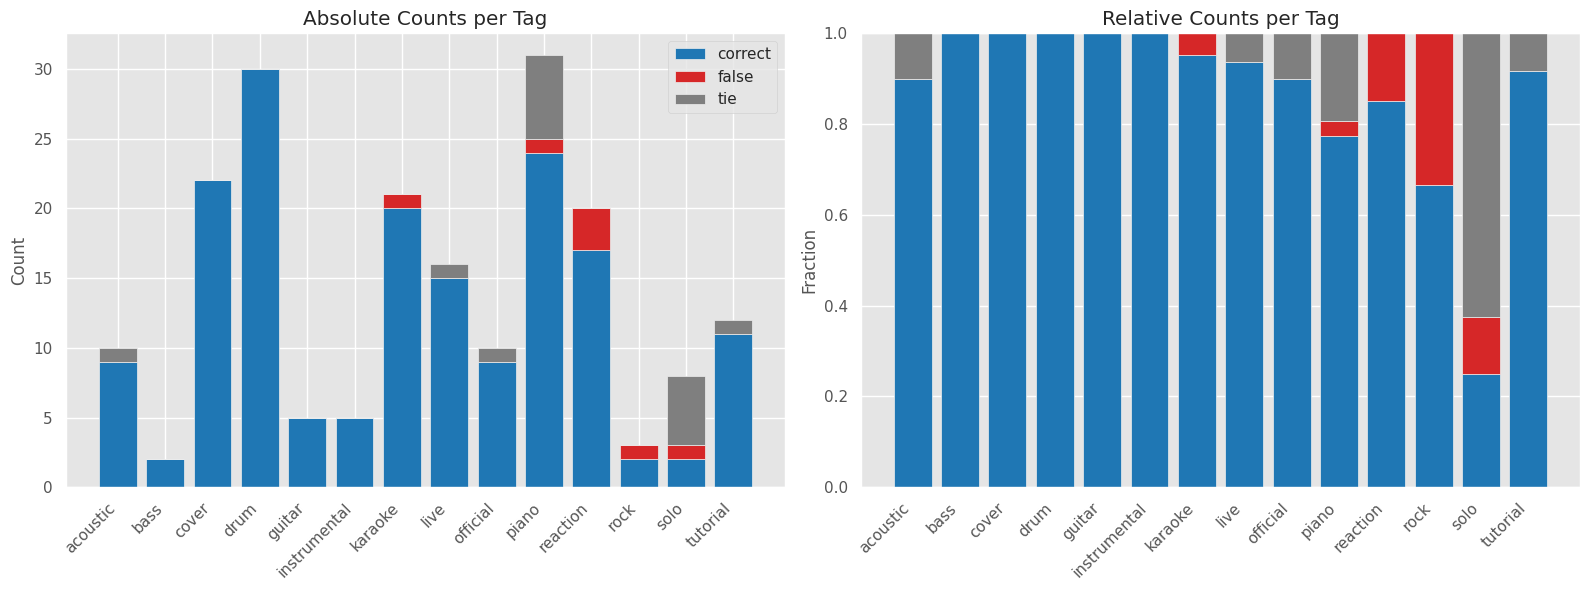

In [155]:
plot_vote_summary(df_long2annots.loc[df_long2annots.tag_in_field == "yt_title"], id_col="tag", vote_col="vote_summary")


Now we also look at the union of agreement rows and rows only annotated by one:

In [156]:
colA, colB = df_wide.columns[:2]

mask_keep = (
    # both values agree (including non-NaN)
    (df_wide[colA] == df_wide[colB]) |
    # or only one is NaN
    (df_wide[colA].isna() ^ df_wide[colB].isna())
)

df_wide2annots_1annot = df_wide.loc[mask_keep]


In [157]:
# Assume df_wide has MultiIndex and two annotator columns
colA, colB = df_wide2annots_1annot.columns[:2]  # first two columns are the annotators
id_cols = df_wide2annots_1annot.index.names       # your ID columns in the MultiIndex

# Reset index to get ID columns as regular columns
df_long2annots_1annot = df_wide2annots_1annot.reset_index().copy()

def summarize_vote_one_nan(a, b):
    """
    Summarize two annotator votes:
    - Both equal → 'correct' (1) or 'false' (0)
    - One NaN, one value → take the value
    - Both different non-NaN → 'tie'
    """
    if pd.isna(a) and not pd.isna(b):
        a = b
    elif pd.isna(b) and not pd.isna(a):
        b = a

    if a == b:
        if a == 1:
            return "correct"
        elif a == 0:
            return "false"
        else:
            return None  # both NaN
    else:
        return "tie"

df_long2annots_1annot["vote_summary"] = df_long2annots_1annot.apply(lambda row: summarize_vote_one_nan(row[colA], row[colB]), axis=1)
df_long2annots_1annot = df_long2annots_1annot[id_cols + ["vote_summary"]]



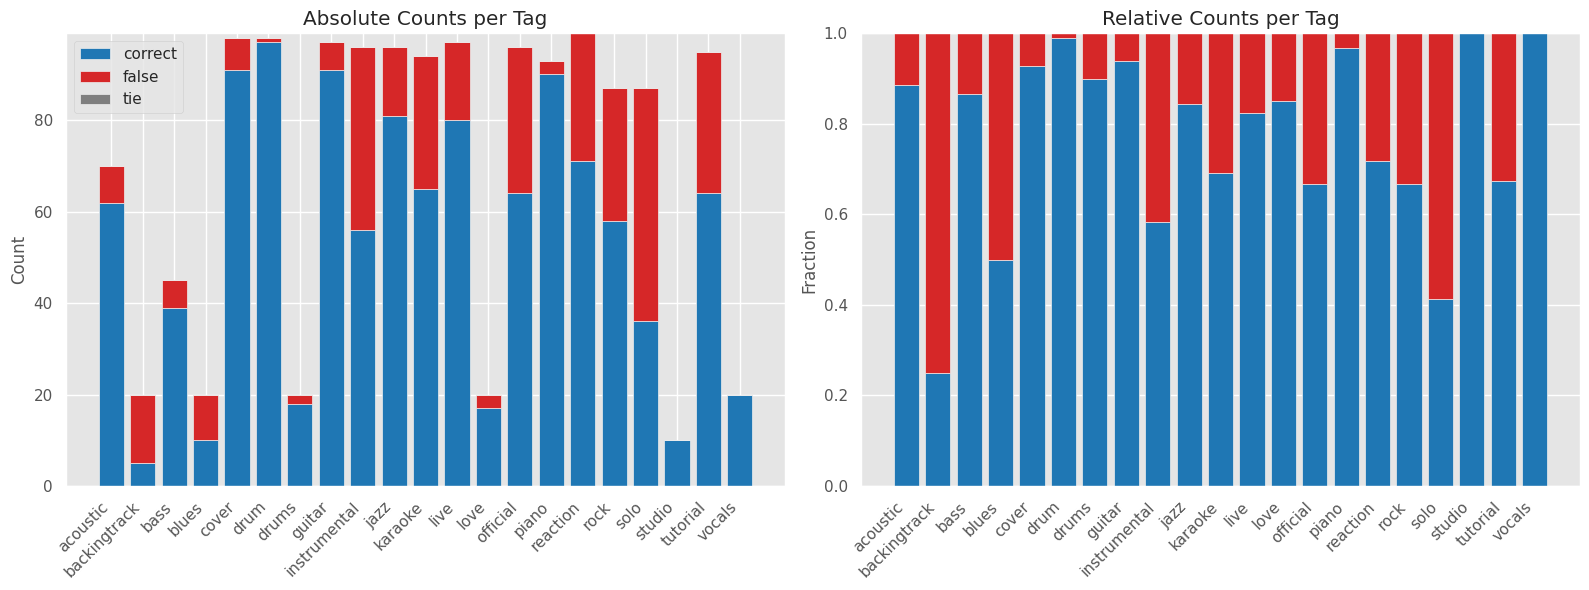

In [158]:
plot_vote_summary(df_long2annots_1annot, id_col="tag", vote_col="vote_summary")


Only in YouTube Title

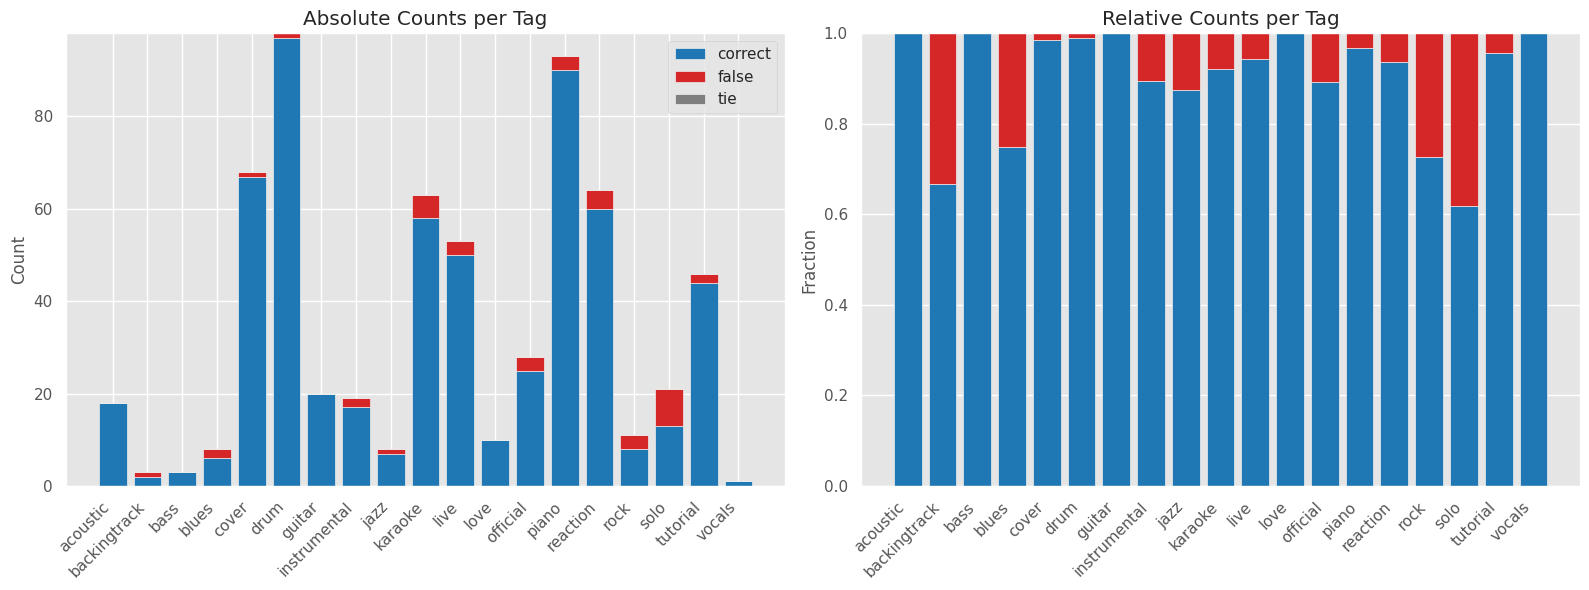

In [159]:
plot_vote_summary(df_long2annots_1annot.loc[df_long2annots_1annot.tag_in_field == "yt_title"], 
                  id_col="tag", vote_col="vote_summary")


### Quality by YouTube field

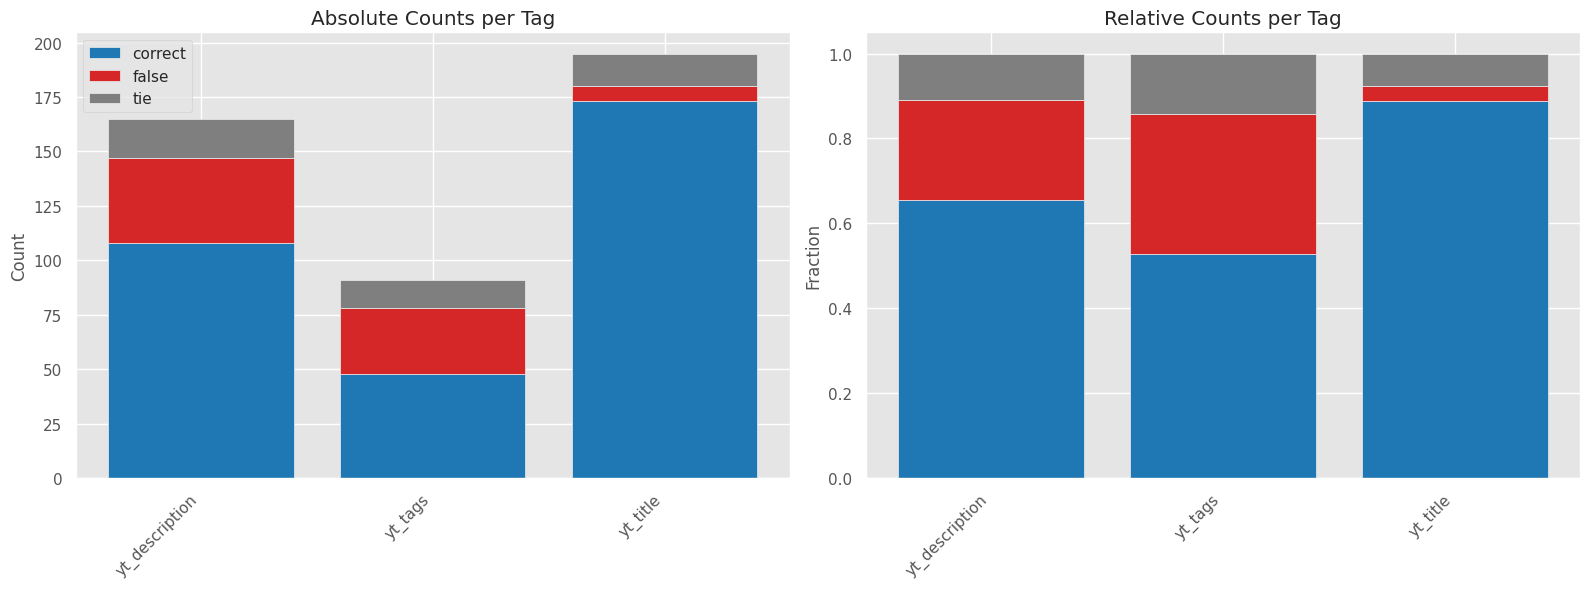

In [160]:
plot_vote_summary(df_long2annots, id_col="tag_in_field", vote_col="vote_summary")
